# 1. IMPORT LIBRARIES

In [1]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier






# 2. LOAD DATA ##


In [2]:
df = pd.read_csv("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
ordered_cols = [

# Personal
'Age', 'Gender', 'Education', 'EducationField', 'MaritalStatus', 'DistanceFromHome',

# Job Entry
'Department', 'JobRole', 'JobLevel', 'BusinessTravel',

# Work Environment
'OverTime', 'WorkLifeBalance', 'EnvironmentSatisfaction', 'JobInvolvement',

# Compensation
'MonthlyIncome', 'DailyRate', 'HourlyRate', 'MonthlyRate',
'PercentSalaryHike', 'StockOptionLevel',

# External Experience
'NumCompaniesWorked', 'TotalWorkingYears',

# Internal Growth
'YearsAtCompany', 'YearsInCurrentRole',
'YearsSinceLastPromotion', 'YearsWithCurrManager',

# Performance
'PerformanceRating', 'TrainingTimesLastYear',

# Target
'Attrition'
]

df = df[ordered_cols]

df.head()

,Age,Gender,Education,EducationField,MaritalStatus,DistanceFromHome,Department,JobRole,JobLevel,BusinessTravel,...,StockOptionLevel,NumCompaniesWorked,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,TrainingTimesLastYear,Attrition
0,41,Female,2,Life Sciences,Single,1,Sales,Sales Executive,2,Travel_Rarely,...,0,8,8,6,4,0,5,3,0,Yes
1,49,Male,1,Life Sciences,Married,8,Research & Development,Research Scientist,2,Travel_Frequently,...,1,1,10,10,7,1,7,4,3,No
2,37,Male,2,Other,Single,2,Research & Development,Laboratory Technician,1,Travel_Rarely,...,0,6,7,0,0,0,0,3,3,Yes
3,33,Female,4,Life Sciences,Married,3,Research & Development,Research Scientist,1,Travel_Frequently,...,0,1,8,8,7,3,0,3,3,No
4,27,Male,1,Medical,Married,2,Research & Development,Laboratory Technician,1,Travel_Rarely,...,1,9,6,2,2,2,2,3,3,No


# 3. DATA UNDERSTANDING


In [4]:
def d_type(x): 
    return{
        "shape": x.shape,
        "columns": x.columns,
        "info": x.info(),
        "describe": x.describe()
        
    }

result = d_type(df)
print(result['shape'])
print(result['columns'])
print(result['info'])
result['describe']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Gender                   1470 non-null   object
 2   Education                1470 non-null   int64 
 3   EducationField           1470 non-null   object
 4   MaritalStatus            1470 non-null   object
 5   DistanceFromHome         1470 non-null   int64 
 6   Department               1470 non-null   object
 7   JobRole                  1470 non-null   object
 8   JobLevel                 1470 non-null   int64 
 9   BusinessTravel           1470 non-null   object
 10  OverTime                 1470 non-null   object
 11  WorkLifeBalance          1470 non-null   int64 
 12  EnvironmentSatisfaction  1470 non-null   int64 
 13  JobInvolvement           1470 non-null   int64 
 14  MonthlyIncome            1470 non-null  

,Age,Education,DistanceFromHome,JobLevel,WorkLifeBalance,EnvironmentSatisfaction,JobInvolvement,MonthlyIncome,DailyRate,HourlyRate,...,PercentSalaryHike,StockOptionLevel,NumCompaniesWorked,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,TrainingTimesLastYear
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,2.912925,9.192517,2.063946,2.761224,2.721769,2.729932,6502.931293,802.485714,65.891156,...,15.209524,0.793878,2.693197,11.279592,7.008163,4.229252,2.187755,4.123129,3.153741,2.799320
std,9.135373,1.024165,8.106864,1.106940,0.706476,1.093082,0.711561,4707.956783,403.509100,20.329428,...,3.659938,0.852077,2.498009,7.780782,6.126525,3.623137,3.222430,3.568136,0.360824,1.289271
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,102.000000,30.000000,...,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,30.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2911.000000,465.000000,48.000000,...,12.000000,0.000000,1.000000,6.000000,3.000000,2.000000,0.000000,2.000000,3.000000,2.000000
50%,36.000000,3.000000,7.000000,2.000000,3.000000,3.000000,3.000000,4919.000000,802.000000,66.000000,...,14.000000,1.000000,2.000000,10.000000,5.000000,3.000000,1.000000,3.000000,3.000000,3.000000
75%,43.000000,4.000000,14.000000,3.000000,3.000000,4.000000,3.000000,8379.000000,1157.000000,83.750000,...,18.000000,1.000000,4.000000,15.000000,9.000000,7.000000,3.000000,7.000000,3.000000,3.000000
max,60.000000,5.000000,29.000000,5.000000,4.000000,4.000000,4.000000,19999.000000,1499.000000,100.000000,...,25.000000,3.000000,9.000000,40.000000,40.000000,18.000000,15.000000,17.000000,4.000000,6.000000


In [5]:
df.isnull().sum()

Age                        0
Gender                     0
Education                  0
EducationField             0
MaritalStatus              0
DistanceFromHome           0
Department                 0
JobRole                    0
JobLevel                   0
BusinessTravel             0
OverTime                   0
WorkLifeBalance            0
EnvironmentSatisfaction    0
JobInvolvement             0
MonthlyIncome              0
DailyRate                  0
HourlyRate                 0
MonthlyRate                0
PercentSalaryHike          0
StockOptionLevel           0
NumCompaniesWorked         0
TotalWorkingYears          0
YearsAtCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
PerformanceRating          0
TrainingTimesLastYear      0
Attrition                  0
dtype: int64

In [6]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

# 4. EDA

In [7]:
categorical_cols= [col for col in df.columns
                  if df[col].dtype== 'object' or df[col].nunique()<10]
categorical_cols

['Gender',
 'Education',
 'EducationField',
 'MaritalStatus',
 'Department',
 'JobRole',
 'JobLevel',
 'BusinessTravel',
 'OverTime',
 'WorkLifeBalance',
 'EnvironmentSatisfaction',
 'JobInvolvement',
 'StockOptionLevel',
 'PerformanceRating',
 'TrainingTimesLastYear',
 'Attrition']

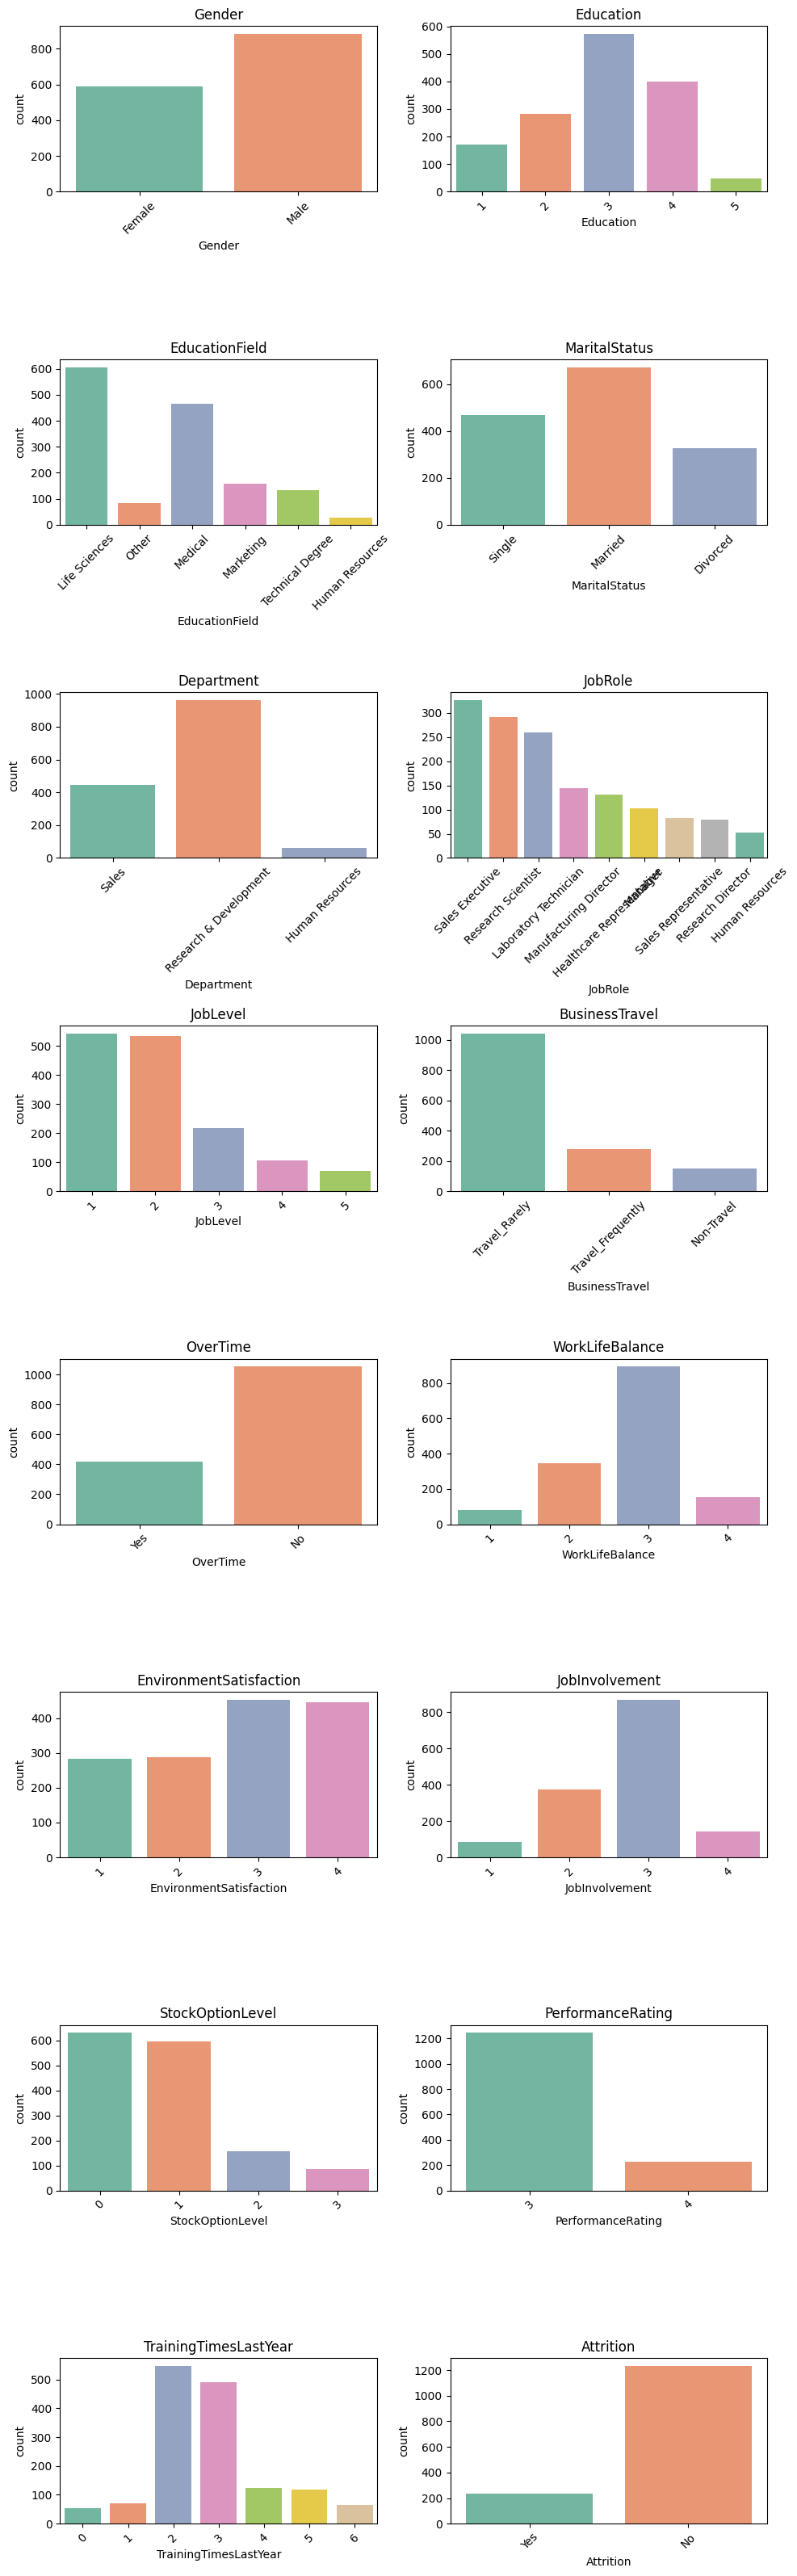

In [8]:

n_cols = 2  # number of plots per row
n_rows = math.ceil(len(categorical_cols) / n_cols)

plt.figure(figsize=(5*n_cols, 4*n_rows))

for idx, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, idx + 1)
    sns.countplot(x=col, data=df, palette='Set2')
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='Attrition', ylabel='count'>

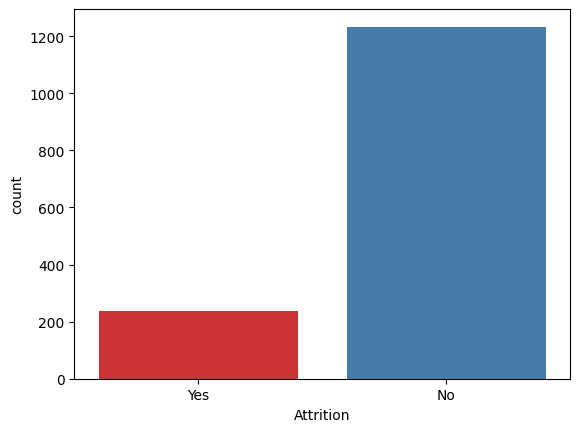

In [9]:
sns.countplot(x='Attrition', data=df, palette='Set1')

In [10]:


n_cols = 3  # plots per row
n_rows = math.ceil(len(non_cat_num_cols) / n_cols)

plt.figure(figsize=(5*n_cols, 4*n_rows))

for idx, col in enumerate(non_cat_num_cols):
    plt.subplot(n_rows, n_cols, idx + 1)
    df[col].hist(bins=20)
    plt.title(col)

plt.tight_layout()
plt.show()

NameError: name 'non_cat_num_cols' is not defined

The organization appears to employ a predominantly young-to-mid-career workforce with moderate experience levels and mostly medium educational backgrounds. Employee tenure suggests reasonable retention, while the training distribution indicates periodic workforce development. Salary distribution is uneven, with many employees concentrated in lower-to-mid income ranges and fewer high-income earners, which reflects a structured organizational hierarchy.

## Bivariate Analysis

In [ ]:
plt.figure(figsize=(12, 8))
corr = df[non_cat_num_cols].corr()
sns.heatmap(corr, annot=False, cmap='YlGnBu', center=0)
plt.title("Correlation Heatmap")
plt.show()

employees with higher experience and longer organizational tenure tend to earn higher salaries, remain longer in the company, stay longer in their current roles, and work with the same managers for extended periods. 

Variables such as TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, and YearsWithCurrManager are strongly interconnected, which suggests that career progression inside the organization follows a relatively stable and tenure-driven structure. 

MonthlyIncome also shows strong positive relationships with experience-related variables, indicating that salary growth is closely tied to accumulated work experience and long-term employment.

In [ ]:
'''I will exclude few cols I feel does not make much difference to the attrition rate.'''


exclude_cols = [
    'DailyRate',
    'HourlyRate',
    'MonthlyRate',
    
    
    
]

non_cat_num_cols = [
    col for col in non_cat_num_cols
    if col not in exclude_cols
]

stastistic analysis, grpah analysis

No of companies, YearsSinceLastPromotion, PercentSalaryHike have weakest relationship to attrition. That means, employees who left, promotion was not a significant factor for them.

### Attrition vs non-attrition comparison

Questions:
Do employees with lower salaries leave more frequently?

Does overtime strongly increase attrition? Yes

Which department has the highest attrition rate? Sales

Are newer employees more likely to leave?

Does poor work-life balance correlate with attrition? Yes, 35% left due to wLB, ENV 25%

Do employees leave more under certain managers or roles?

Does promotion delay increase resignation probability? No

Does commuting distance influence attrition?

Are younger employees leaving more often?

Which satisfaction metric has the strongest relationship with attrition? Env, WLB

In [ ]:
ttest_results = []

for col in non_cat_num_cols:

    left = df[df['Attrition'] == 'Yes'][col]
    stay = df[df['Attrition'] == 'No'][col]

    stat, p = ttest_ind(left, stay)

    ttest_results.append({
        'Feature': col,
        'T-Statistic': stat,
        'P-Value': p
    })

ttest_df = pd.DataFrame(ttest_results)

# Function to classify strength
def get_strength(p):
    if p < 0.001:
        return 'Strong'
    elif p < 0.01:
        return 'Moderate'
    elif p < 0.05:
        return 'Weak'
    else:
        return 'Not Significant'

# Apply classification
ttest_df['Relationship'] = ttest_df['P-Value'].apply(get_strength)

# Sort for readability
ttest_df = ttest_df.sort_values(by='P-Value')

print(ttest_df)

In [ ]:
chi_results = []

for col in categorical_cols:

    contingency = pd.crosstab(df[col], df['Attrition'])

    chi2, p, dof, expected = chi2_contingency(contingency)

    chi_results.append({
        'Feature': col,
        'Chi2': chi2,
        'P-Value': p
    })

chi_df = pd.DataFrame(chi_results)

# Function to classify strength
def get_strength(p):
    if p < 0.001:
        return 'Strong'
    elif p < 0.01:
        return 'Moderate'
    elif p < 0.05:
        return 'Weak'
    else:
        return 'Not Significant'

# Apply classification
chi_df['Relationship'] = chi_df['P-Value'].apply(get_strength)

# Sort by importance (Strong → Not Significant via p-value)
chi_df = chi_df.sort_values(by='P-Value')

print(chi_df)

SO gender, education and performance rating have weakes relationship to attrition. We will validate this further and then remove it later.

In [ ]:
(df['Attrition'].value_counts(normalize=True) * 100)

# Calculate percentage
attrition_percent = (df['Attrition'].value_counts(normalize=True) * 100)

# Soft pastel colors
colors = ['#A8DADC', '#F4A6A6']

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    attrition_percent,
    labels=attrition_percent.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)

plt.title('Attrition Distribution', fontsize=14)
plt.tight_layout()
plt.show()

### Categorical

In [ ]:
sns.set_style("whitegrid")

features = [
    'OverTime', 'JobRole', 'JobLevel', 'StockOptionLevel',
    'MaritalStatus', 'JobInvolvement', 'BusinessTravel',
    'EnvironmentSatisfaction', 'WorkLifeBalance', 'Department',
    'EducationField', 'TrainingTimesLastYear',
    'Gender', 'Education', 'PerformanceRating'
]

n_cols = 2
n_rows = (len(features) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Soft pastel palette
pastel_colors = sns.color_palette("rocket", 10)

for i, col in enumerate(features):
    ax = axes[i]

    # Calculate attrition rate
    temp = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values()

    # Different soft colors for each bar
    colors = pastel_colors[:len(temp)]

    bars = ax.barh(
        temp.index,
        temp.values,
        color=colors,
        edgecolor='white',
        linewidth=1.5
    )

    # Titles and labels
    ax.set_title(
        f"Attrition Rate by {col}",
        fontsize=14,
        weight='bold'
    )

    ax.set_xlabel("Attrition Rate (%)", fontsize=11)
    ax.set_ylabel("")

    # Soft background
    ax.set_facecolor('#FAFAFA')

    # Remove top/right spines
    sns.despine(ax=ax)

    # Limit for labels
    ax.set_xlim(0, max(temp.values) + 10)

    # Percentage labels
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10
        )

plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

It's clear from the percentages that most differenting factors have attrition percentages more than 20%.
Gender, Education, Percentagerating not only have minimal differences in the percentages, these are below 20%. This confirms the Chi-square test that these do not contribute to the attrition rate.

employees who left the organization generally had lower median monthly income compared to those who stayed

## Behavioural Analysis

In [ ]:
'''Function for boxplot and bayesian'''


def boxplot_with_bayes(df, x_col, target='Attrition', positive_class='Yes', bins=10, title=None):
    """
    Plots:
    1. Boxplot of x_col vs target
    2. Bayesian-style conditional probability curve P(target=positive_class | x_col bins)
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # -------------------------
    # 1. BOX PLOT
    # -------------------------
    sns.boxplot(data=df, x=target, y=x_col, ax=axes[0])
    axes[0].set_title(f"{x_col} vs {target}")

    # -------------------------
    # 2. BAYESIAN STYLE PLOT
    # -------------------------
    df_copy = df[[x_col, target]].dropna().copy()

    # create bins
    df_copy['bin'] = pd.cut(df_copy[x_col], bins=bins)

    # compute probabilities
    prob = df_copy.groupby('bin')[target].apply(
        lambda x: (x == positive_class).mean()
    ).reset_index(name='P(Yes)')

    # midpoints for plotting
    prob['mid'] = prob['bin'].apply(lambda x: x.mid)

    axes[1].plot(prob['mid'], prob['P(Yes)'], marker='o')
    axes[1].set_title(f"P({positive_class} | {x_col})")
    axes[1].set_xlabel(x_col)
    axes[1].set_ylabel("Probability")

    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()

In [ ]:

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome',
    ax=axes[0]
)

axes[0].set_title(
    "Monthly Income vs Attrition",
    fontsize=14,
    weight='bold'
)

df['IncomeBand'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['Low','Mid','High','Very High'])

sns.countplot(data=df, x='IncomeBand', hue='Attrition')
plt.title("Attrition across Income Bands")

plt.tight_layout()
plt.show()

In [ ]:
income_points = [1000, 2000, 5000, 10000, 15000, 20000, 50000, 100000]

p_yes_list = []

for x in income_points:
    subset = df[df['MonthlyIncome'] <= x]
    
    if len(subset) > 0:
        p_yes = (subset['Attrition'] == 'Yes').mean()
    else:
        p_yes = np.nan  # no data in this range
    
    p_yes_list.append(p_yes)

# Plot
plt.figure(figsize=(8,5))
plt.plot(income_points, p_yes_list, marker='o')

plt.xlabel("Income Threshold (x)")
plt.ylabel("P(Attrition = Yes | Income ≤ x)")
plt.title("Tendency of Leaving vs Income Threshold")

plt.grid(True)
plt.show()

In [ ]:
age_points = [20, 25, 30, 35, 40, 45, 50, 60]

p_yes = [
    (df[df['Age'] <= x]['Attrition'] == 'Yes').mean()
    for x in age_points
]

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Boxplot
sns.boxplot(data=df, x='Attrition', y='Age', ax=ax[0])
ax[0].set_title("Age vs Attrition")

# Bayesian curve
ax[1].plot(age_points, p_yes, marker='o')
ax[1].set_xlabel("Age ≤ x")
ax[1].set_ylabel("P(Yes | Age ≤ x)")
ax[1].set_title("Younger Employees Leaving Trend")
ax[1].grid()

plt.tight_layout()
plt.show()

In [ ]:
features = [
    
    "TotalWorkingYears",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "YearsAtCompany",
    "DistanceFromHome",
    "NumCompaniesWorked",
    "YearsSinceLastPromotion",
    "PercentSalaryHike"
]

def plot_multiple_box_bayes(df, feature_list, target='Attrition', positive_class='Yes', bins=5):
    for col in feature_list:
        print(f"\n=== Plotting: {col} ===")
        
        boxplot_with_bayes(
            df=df,
            x_col=col,
            target=target,
            positive_class=positive_class,
            bins=bins,
            title=f"{col} Analysis"
        )

In [ ]:
plot_multiple_box_bayes(df, features)